## Imports

In [3]:
import sys
!{sys.executable} -m pip install scanpy -q

In [4]:
import scanpy as sc
import pandas as pd

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns

import torch # loads PyTorch
import torch.nn as nn # gives neural network layers
import torch.nn.functional as F # gives loss functions
import torch.distributions as dist # lets us define probability distributions
from torch.utils.data import TensorDataset, DataLoader # lets us train in batches instead of feeding all 50,000 cells at once

import matplotlib.pyplot as plt
import numpy as np

## Check RNA sequencing thalamus file

In [7]:
# load thalamus scRNA-seq dataset
adata = sc.read_h5ad("scRNAseq/Reduced matrices/WMB-10Xv3-TH-log2_MERFISHgenes.h5ad")

print("dataset shape:", adata.shape)

print("observation columns:", adata.obs.columns)

print("first 5 cells:", adata.obs.head())

print("expression matrix type:",type(adata.X))


dataset shape: (130856, 500)
observation columns: Index(['cell_barcode', 'library_label', 'anatomical_division_label'], dtype='object')
first 5 cells:                               cell_barcode       library_label  \
cell_label                                                       
AGAAGTATCATTACGG-290_B01  AGAAGTATCATTACGG  L8TX_200716_01_B06   
TTGACCCCAGGCCTGT-290_B01  TTGACCCCAGGCCTGT  L8TX_200716_01_B06   
AATGCCATCGCTAATG-290_B01  AATGCCATCGCTAATG  L8TX_200716_01_B06   
TGCGATAAGTCATGGG-290_B01  TGCGATAAGTCATGGG  L8TX_200716_01_B06   
CATCCCAAGATCCGAG-294_B05  CATCCCAAGATCCGAG  L8TX_200716_01_H06   

                         anatomical_division_label  
cell_label                                          
AGAAGTATCATTACGG-290_B01                        TH  
TTGACCCCAGGCCTGT-290_B01                        TH  
AATGCCATCGCTAATG-290_B01                        TH  
TGCGATAAGTCATGGG-290_B01                        TH  
CATCCCAAGATCCGAG-294_B05                        TH  
expression matr

## Build labels for cells

In [8]:
# cell metadata from h5ad thalamus file
cells = adata.obs.reset_index()

# load rna-seq metadata that maps each cell to a cluster alias
meta = pd.read_csv("scRNAseq/cell_metadata_rna.csv")

cells = cells.merge(
    meta[["cell_label", "cluster_alias"]],
    on="cell_label",
    how="left"
)

# remove cells without a cluster assignment
cells = cells.dropna(subset=["cluster_alias"])
cells["cluster_alias"] = cells["cluster_alias"].astype(int)

# load taxonomy mapping from cluster aliases to annotation labels
membership = pd.read_csv(
    "Taxonomy/cluster_to_cluster_annotation_membership.csv"
)

# keep only the cell class labels (highest level in cell-typing hierarchy)
class_labels = membership[
    membership["cluster_annotation_term_set_name"] == "class"
][["cluster_alias", "cluster_annotation_term_name"]]

class_labels = class_labels.rename(
    columns={"cluster_annotation_term_name": "class_label"}
)

# attach class labels to each cell
cells = cells.merge(
    class_labels,
    on="cluster_alias",
    how="left"
)

# checks
print("number of cells with labels:", len(cells))
print("missing class labels:", cells["class_label"].isna().sum())
print("class counts:")
print(cells["class_label"].value_counts())

number of cells with labels: 130454
missing class labels: 0
class counts:
class_label
18 TH Glut           45183
31 OPC-Oligo         41126
30 Astro-Epen        11008
33 Vascular           6709
12 HY GABA            6638
19 MB Glut            6485
17 MH-LH Glut         6032
20 MB GABA            4306
34 Immune             2438
14 HY Glut             198
09 CNU-LGE GABA         93
13 CNU-HYa Glut         73
11 CNU-HYa GABA         34
01 IT-ET Glut           30
04 DG-IMN Glut          22
06 CTX-CGE GABA         20
08 CNU-MGE GABA         16
03 OB-CR Glut           16
21 MB Dopa              10
24 MY Glut               4
02 NP-CT-L6b Glut        4
07 CTX-MGE GABA          3
05 OB-IMN GABA           3
23 P Glut                2
15 HY Gnrh1 Glut         1
Name: count, dtype: int64


## Remove classes with very few examples

In [9]:
# remove classes with fewer than 100 cells

counts = cells["class_label"].value_counts()

valid_classes = counts[counts >= 100].index

cells = cells[
    cells["class_label"].isin(valid_classes)
]

# checks

print("remaining classes:",cells["class_label"].nunique())
print("remaining cells:", len(cells))

print("class distribution:")
print(cells["class_label"].value_counts())

remaining classes: 10
remaining cells: 130123
class distribution:
class_label
18 TH Glut       45183
31 OPC-Oligo     41126
30 Astro-Epen    11008
33 Vascular       6709
12 HY GABA        6638
19 MB Glut        6485
17 MH-LH Glut     6032
20 MB GABA        4306
34 Immune         2438
14 HY Glut         198
Name: count, dtype: int64


In [10]:
# keep only cells that still have valid class labels

valid_cell_labels = set(cells["cell_label"])

adata_filtered = adata[
    adata.obs.index.isin(valid_cell_labels)
]

# make sure expression matrix and labels contain the same cells

assert adata_filtered.shape[0] == len(cells)

## Build feature matrix and class labels

In [11]:
# build feature matrix (X) and class labels (y)

# contains gene expression matrix
    # rows = cells, columns = genes
    # shape = (number of cells, 500 genes)
X = adata_filtered.X

# class label assigned to each cell
# the targets that the classifier will try to predict
y = cells["class_label"]

print("expression matrix shape:", X.shape)
print("number of labels:", len(y))

expression matrix shape: (130123, 500)
number of labels: 130123


## Create 50,000 cell subset

In [12]:
X_dense = X.toarray()

# sample 50,000 cells
# preserve original class proportions
X_subset, _, y_subset, _ = train_test_split(
    X_dense,
    y,
    train_size=50000,
    stratify=y,
    random_state=0
)

# ensure x and y subsets align
assert X_subset.shape[0] == len(y_subset)

print("subset shape:", X_subset.shape)

subset shape: (50000, 500)


## Create cross-validated cell type classifier

In [13]:
def cross_validated_classifier(X_representation, y, method_name):

    # logistic regression classifier to predict cell type
    clf = LogisticRegression(
        max_iter=3000, # to allow enough iterations for convergence
        class_weight="balanced" # compensate for class imbalance
    )

    # 5-fold stratified cross-validation
    # original class proportions preserved for each fold
    cv = StratifiedKFold(
        n_splits=5, 
        shuffle=True,
        random_state=0
    )

    scores = cross_val_score(
        clf,
        X_representation,
        y,
        cv=cv,
        scoring="balanced_accuracy"
    )

    # summary of results
    print(method_name)
    print("fold scores:", scores)
    print("mean balanced accuracy:", scores.mean())
    print("std:", scores.std())

    return scores

## Run PCA

In [14]:
# reduce 500-dimension gene expression space to 10 dimensions
pca = PCA(n_components=10) 

# learn PCs and project each cell into 10-d latent space
X_pca = pca.fit_transform(X_subset)

print("PCA embedding shape:", X_pca.shape) 

# fraction of total variance captured by first 10 principal components
print(
    "explained variance:",
    pca.explained_variance_ratio_.sum()
)

# evaluate PCA
pca_scores = cross_validated_classifier(
    X_pca,
    y_subset,
    "PCA"
)

PCA embedding shape: (50000, 10)
explained variance: 0.5150775
PCA
fold scores: [0.915816   0.93105739 0.93908984 0.9135269  0.90539827]
mean balanced accuracy: 0.9209776802174815
std: 0.012284349883031787


## Run FA

In [15]:
# reduce 500-dimension gene expression space to 10 dimensions
fa = FactorAnalysis(n_components=10)

# learn latent factors and project each cell into 10-d latent space
X_fa = fa.fit_transform(X_subset)

print("FA embedding shapee:", X_fa.shape)

# evaluate FA
fa_scores = cross_validated_classifier(
    X_fa,
    y_subset,
    "FactorAnalysis"
)

FA embedding shapee: (50000, 10)
FactorAnalysis
fold scores: [0.93002625 0.91549855 0.93698182 0.91683554 0.91440906]
mean balanced accuracy: 0.922750242911231
std: 0.00908431838183944


## VAE

### VAE preparation

In [16]:
X_tensor = torch.tensor(X_subset, dtype=torch.float32) 

dataset = TensorDataset(X_tensor)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

### Define VAE

In [17]:
class VAE(nn.Module):

    # input dim = 500 genes measured per cell
    # hidden dim = size of intermediate neural network layers
    # latent_dim = size of learned embedding (10 to match PCA and FA)
    def __init__(self, input_dim=500, hidden_dim=128, latent_dim=10):

        super().__init__() 

        # saves latent dimensionality we can split the encoder output later
        self.latent_dim = latent_dim 

        # encoder: maps 500 gene-expression values to paremeters
            # of a latent gaussian distribution q(z|x)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), # first encoder layer
            nn.ReLU(), # introduces non-linearity
            nn.Linear(256, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * latent_dim) # final encoder layer
        )

        # decoder: maps latent values back to reconstructed
            # 500-dimensional gene-expression profiles
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), # first decoder layer
            nn.ReLU(), # introduces non-linearity
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim) # final decoder layer
        )

    def encode(self, x):

        params = self.encoder(x) 

        mu, log_sigma = torch.split(
            params,
            self.latent_dim,
            dim=1
        )

        # convert log std to std
        sigma = torch.exp(log_sigma)

        # approximate q(z|x)
        q_z = dist.Independent(
            dist.Normal(
                loc=mu,
                scale=sigma
            ),
            1
        )

        return q_z, mu

    def decode(self, z):

        # reconstruct gene-expression profile
            # from latent representation
        x_hat = self.decoder(z)

        return x_hat
    
    def forward(self, x):

        # encode input into latent distribution
        q_z, mu = self.encode(x)

        # sample latent representation w reparameterization
        z = q_z.rsample()

        # decode sampled latent representation
        x_hat = self.decode(z)

        return x_hat, q_z, mu

In [18]:
vae = VAE()

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

### VAE loss function

In [19]:
# x = original gene-expression profiles
# x_hat = reconstructed gene expression profiles
# q_z = approximate posterior distribution learned by encoder

def vae_loss(x_hat, x, q_z):

    recon_loss = F.mse_loss(
        x_hat,
        x,
        reduction="sum" # adds the errors across genes and cells
    )
    
    prior = dist.Independent( # treat all 10 latent dimensions as independent gaussian variables
        dist.Normal( # creates a gaussian
            loc = torch.zeros_like(q_z.base_dist.loc), 
            scale = torch.ones_like(q_z.base_dist.scale) 
        ),
        1
    )

    # KL divergence
    kl_loss = dist.kl_divergence(q_z, prior).sum()

    total_loss = recon_loss + kl_loss

    return total_loss, recon_loss, kl_loss

### Train VAE

In [20]:
n_epochs = 100

# early stopping settings
best_loss = float("inf")
patience = 5
min_delta = 0.2
epochs_without_improvement = 0

# store for visualization
losses = []
recon_losses = []
kl_losses = []

len_dataset = len(dataset)

# put model in training mode
vae.train() 

for epoch in range(n_epochs):

    # accumulate losses across all batches
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch in dataloader:

        # extract batch of gene expression profiles
        x_batch = batch[0]

        # reset gradients from previous batch
        optimizer.zero_grad() 

        # forward pass through VAE
        x_hat, q_z, mu = vae(x_batch) 

        # compute losses
        loss, recon_loss, kl_loss = vae_loss(
            x_hat,
            x_batch,
            q_z
        )

        # backpropagate gradients
        loss.backward()

        # update model parameters
        optimizer.step()

        # store batch losses
        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    # average loss per cell
    avg_loss = total_loss / len_dataset
    avg_recon = total_recon / len_dataset
    avg_kl = total_kl / len_dataset

    losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(
        f"epoch {epoch + 1}: "
        f"loss={avg_loss:.4f}, "
        f"recon={avg_recon:.4f}, "
        f"KL={avg_kl:.4f}"
    )

    if best_loss - avg_loss > min_delta:

        best_loss = avg_loss
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print(f"early stopping at epoch {epoch + 1}")
        break

# save trained model weights
torch.save(vae.state_dict(), "vae_model.pt")

epoch 1: loss=1730.1001, recon=1698.3685, KL=31.7316
epoch 2: loss=1278.1476, recon=1247.8832, KL=30.2644
epoch 3: loss=1199.6779, recon=1169.6270, KL=30.0509
epoch 4: loss=1156.9039, recon=1126.8304, KL=30.0735
epoch 5: loss=1130.1783, recon=1100.1794, KL=29.9989
epoch 6: loss=1112.2251, recon=1082.3581, KL=29.8670
epoch 7: loss=1098.6900, recon=1068.9185, KL=29.7715
epoch 8: loss=1088.2835, recon=1058.5846, KL=29.6989
epoch 9: loss=1079.0566, recon=1049.4176, KL=29.6390
epoch 10: loss=1071.5853, recon=1041.9491, KL=29.6362
epoch 11: loss=1065.1981, recon=1035.5693, KL=29.6287
epoch 12: loss=1059.4395, recon=1029.9046, KL=29.5349
epoch 13: loss=1054.8734, recon=1025.3082, KL=29.5652
epoch 14: loss=1050.2758, recon=1020.7713, KL=29.5045
epoch 15: loss=1046.6664, recon=1017.2097, KL=29.4567
epoch 16: loss=1043.3750, recon=1013.8860, KL=29.4890
epoch 17: loss=1039.8931, recon=1010.4340, KL=29.4592
epoch 18: loss=1037.3226, recon=1007.8723, KL=29.4503
epoch 19: loss=1034.7751, recon=1005.

### Evaluate VAE

In [21]:
# switch model to evaluation mode
vae.eval()

# generate latent representations for all cells in the subset
with torch.no_grad():
    q_z, mu = vae.encode(X_tensor)
    X_vae = mu.numpy()

print ("VAE embedding shape:", X_vae.shape)

vae_scores = cross_validated_classifier(
    X_vae,
    y_subset,
    "VAE"
)

VAE embedding shape: (50000, 10)
VAE
fold scores: [0.97719768 0.98264927 0.98639617 0.98253078 0.98525612]
mean balanced accuracy: 0.9828060045409769
std: 0.003176349336000311


# Figures / Analysis

## Classification performance

  Method  Mean Balanced Accuracy       Std
0    PCA                0.920978  0.012284
1     FA                0.922750  0.009084
2    VAE                0.982806  0.003176


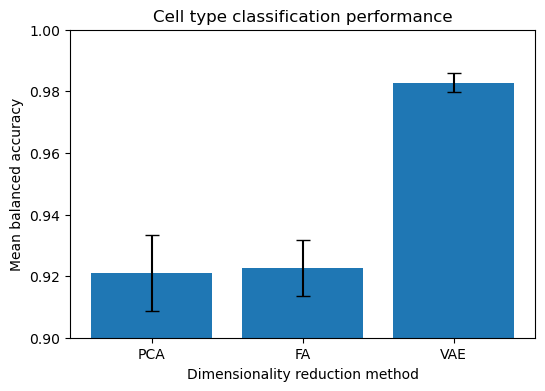

In [22]:
# summarize cross-validated classifier performance for each representation

results = pd.DataFrame({
    "Method": ["PCA", "FA", "VAE"],
    "Mean Balanced Accuracy": [
        pca_scores.mean(),
        fa_scores.mean(),
        vae_scores.mean()
    ],
    "Std": [
        pca_scores.std(),
        fa_scores.std(),
        vae_scores.std()
    ]
})

print(results)

plt.figure(figsize=(6, 4))
plt.bar(
    results["Method"],
    results["Mean Balanced Accuracy"],
    yerr=results["Std"],
    capsize=5
)

plt.xlabel("Dimensionality reduction method")
plt.ylabel("Mean balanced accuracy")
plt.title("Cell type classification performance")
plt.ylim(0.9, 1.0)
plt.show()

## PCA explained variance

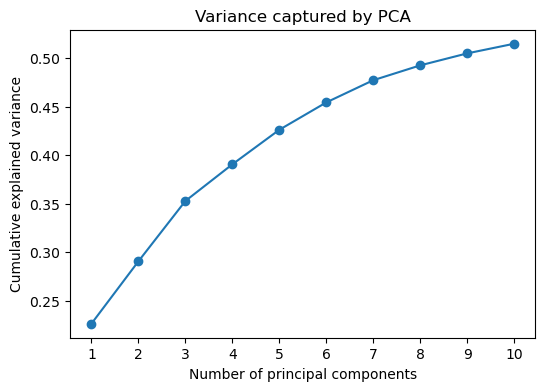

In [23]:
# compute cumulative variance explained by PCA components

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# plot
plt.figure(figsize=(6, 4))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Variance captured by PCA")
plt.xticks(np.arange(1, len(cumulative_variance) + 1))
plt.show()

## VAE training curves

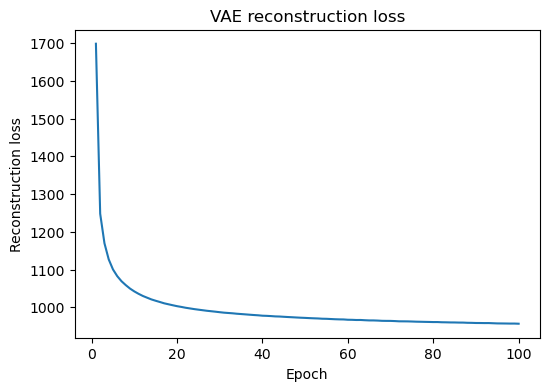

In [24]:
epochs = np.arange(1, len(recon_losses) + 1)

plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    recon_losses
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("VAE reconstruction loss")

plt.show()

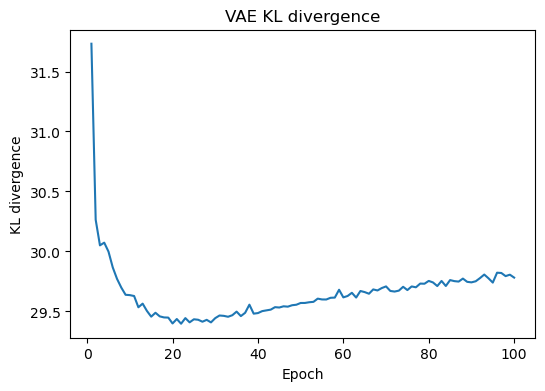

In [25]:
epochs = np.arange(1, len(kl_losses) + 1)

plt.figure(figsize=(6, 4))

plt.plot(
    epochs,
    kl_losses
)

plt.xlabel("Epoch")
plt.ylabel("KL divergence")
plt.title("VAE KL divergence")

plt.show()

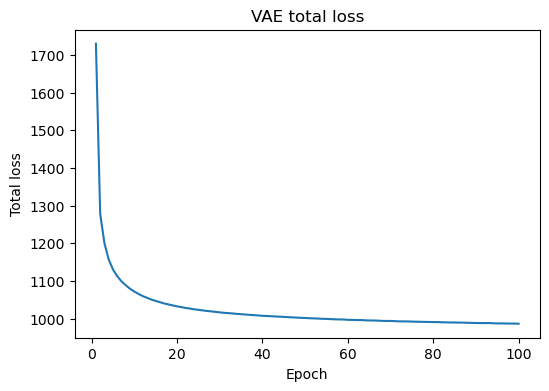

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(losses) + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("VAE total loss")
plt.show()

## 2D embeddings

In [27]:
def plot_2d_embedding(X_embedding, y_labels, title, x_label, y_label):
   
    plot_df = pd.DataFrame({
        "dim1": X_embedding[:, 0],
        "dim2": X_embedding[:, 1],
        "class_label": y_labels.values
    })

    plt.figure(figsize=(7, 5))

    for class_name in plot_df["class_label"].unique():
        class_data = plot_df[
            plot_df["class_label"] == class_name
        ]

        plt.scatter(
            class_data["dim1"],
            class_data["dim2"],
            s=5,
            alpha=0.5,
            label=class_name
        )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(
        markerscale=3,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )
    plt.show()

#### PCA embedding

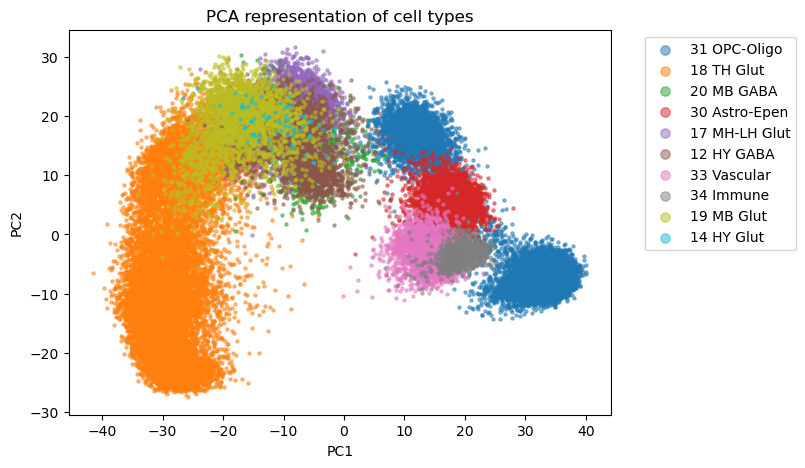

In [28]:
# plot first 2 PCs

plot_2d_embedding(
    X_pca,
    y_subset,
    "PCA representation of cell types",
    "PC1",
    "PC2"
)

#### FA embedding

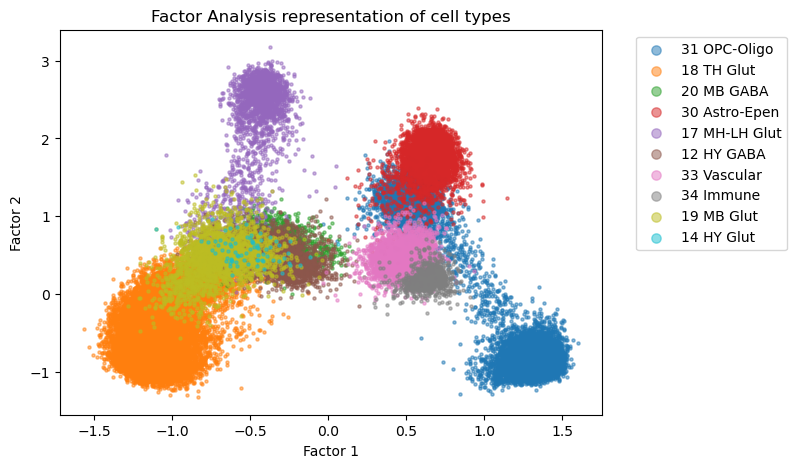

In [29]:
# plot first 2 latent factors

plot_2d_embedding(
    X_fa,
    y_subset,
    "Factor Analysis representation of cell types",
    "Factor 1",
    "Factor 2"
)

#### VAE embedding

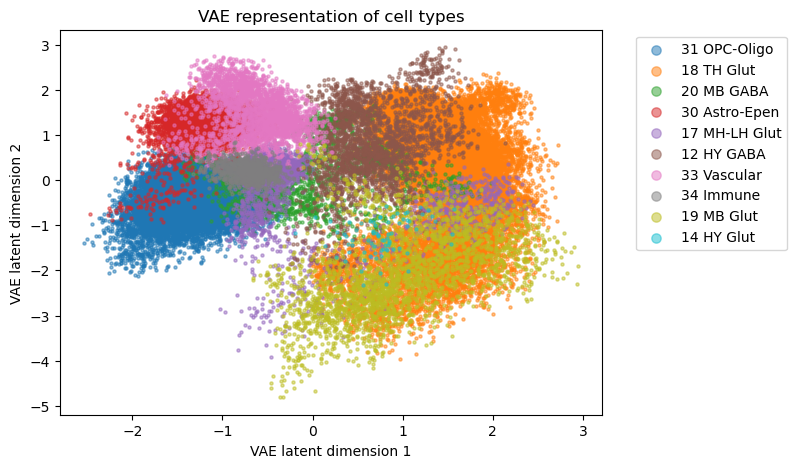

In [30]:
# reduce VAE latent space to 2D to allow for visualization

vae_pca_2d = PCA(n_components=2)

X_vae_2d = vae_pca_2d.fit_transform(X_vae)

plot_2d_embedding(
    X_vae_2d,
    y_subset,
    "VAE representation of cell types",
    "VAE latent dimension 1",
    "VAE latent dimension 2"
)

#### VAE confusion matrix

In [31]:
# get predictions for each cell

clf = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

y_pred = cross_val_predict(
    clf,
    X_vae,
    y_subset,
    cv=cv
)

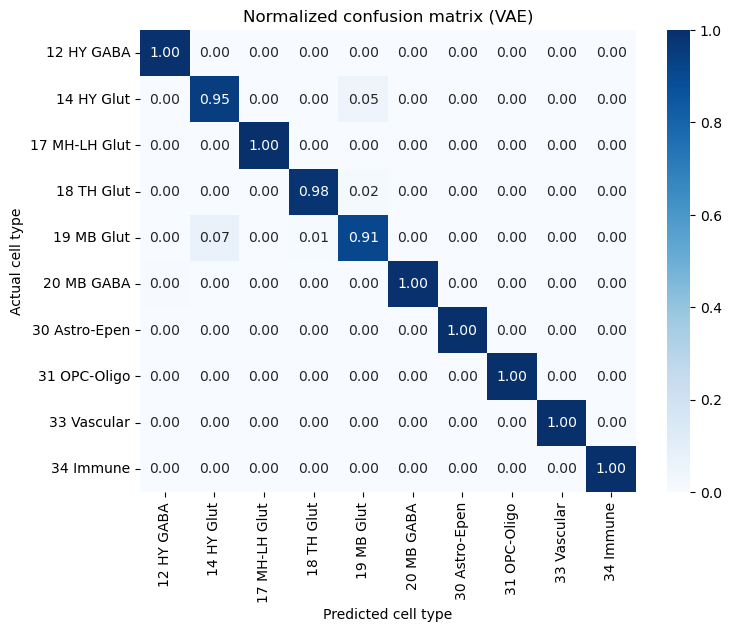

In [32]:
cm = confusion_matrix(
    y_subset,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=np.unique(y_subset),
    yticklabels=np.unique(y_subset),
    vmin=0,
    vmax=1
)

plt.xlabel("Predicted cell type")
plt.ylabel("Actual cell type")
plt.title("Normalized confusion matrix (VAE)")

plt.show()